In [ ]:
PROJECT_NAME = "FSFM-Lite"
IMG_SIZE = 224
PADDING = 0.20
print(PROJECT_NAME)

FSFM-Lite


In [2]:
from pathlib import Path

import cv2
import numpy as np
import pandas as pd

from PIL import Image

import matplotlib.pyplot as plt

import torch
from torch.utils.data import Dataset
from torchvision import transforms

In [3]:
PROJECT_ROOT = Path("D:\code\FSFM_Lite_Project")

DATA_ROOT = PROJECT_ROOT / "data" / "CelebA_Spoof"

METADATA_ROOT = PROJECT_ROOT / "metadata"

In [4]:
train_df = pd.read_csv(METADATA_ROOT / "train_df.csv")

test_df = pd.read_csv(METADATA_ROOT / "test_df.csv")

In [5]:
def read_bbox(bb_path):

    with open(bb_path, "r") as f:

        line = f.readline().strip()

    values = line.split()

    x = int(float(values[0]))
    y = int(float(values[1]))
    w = int(float(values[2]))
    h = int(float(values[3]))

    conf = float(values[4])

    return x, y, w, h, conf


sample_bb = train_df.iloc[0]["bb_path"]

print(read_bbox(sample_bb))

(15, 30, 146, 166, 0.99992573)


In [7]:
def crop_face(image_path, bb_path, padding=0.20):

    img = cv2.imread(str(image_path))

    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # Read bbox
    x, y, w, h, conf = read_bbox(bb_path)

    # Original image size
    H, W = img.shape[:2]

    # Convert bbox from 224-space -> real image space
    x = int(x * (W / 224))
    y = int(y * (H / 224))

    w = int(w * (W / 224))
    h = int(h * (H / 224))

    # Padding
    pad_w = int(w * padding)
    pad_h = int(h * padding)

    x1 = max(0, x - pad_w)
    y1 = max(0, y - pad_h)

    x2 = min(W, x + w + pad_w)
    y2 = min(H, y + h + pad_h)

    face = img[y1:y2, x1:x2]

    return face

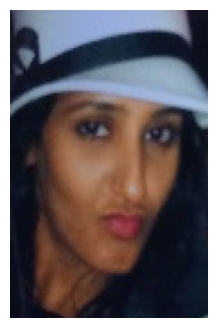

In [8]:
sample = train_df.sample(1, random_state=42).iloc[0]

face = crop_face(sample.image_path, sample.bb_path)

plt.figure(figsize=(4, 4))

plt.imshow(face)

plt.axis("off")

plt.show()

In [9]:
face_transform = transforms.Compose(
    [
        transforms.ToPILImage(),
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ]
)

In [10]:
class CelebASpoofDataset(Dataset):

    def __init__(self, dataframe, transform=None):

        self.df = dataframe

        self.transform = transform

    def __len__(self):

        return len(self.df)

    def __getitem__(self, idx):

        row = self.df.iloc[idx]

        face = crop_face(row.image_path, row.bb_path)

        label = row.label

        if self.transform:

            face = self.transform(face)

        return {"image": face, "label": torch.tensor(label, dtype=torch.long)}

In [11]:
train_dataset = CelebASpoofDataset(train_df, transform=face_transform)

sample = train_dataset[0]

print(sample["image"].shape)

print(sample["label"])

torch.Size([3, 224, 224])
tensor(1)


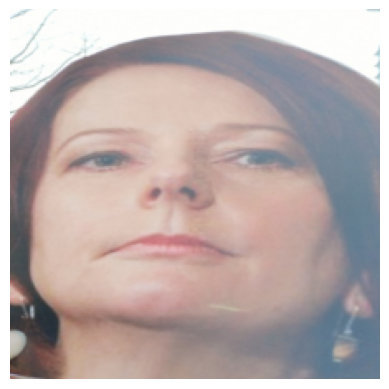

In [12]:
img = sample["image"]

img = img.permute(1, 2, 0)

img = img.numpy()

img = img * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])

img = np.clip(img, 0, 1)

plt.imshow(img)

plt.axis("off")

plt.show()

In [15]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent

sys.path.append(str(PROJECT_ROOT))

print(PROJECT_ROOT)

d:\code\FSFM_Lite_Project


In [16]:
from src.datasets.celeba_spoof_dataset import read_bbox, crop_face, CelebASpoofDataset

print("Import OK")

Import OK
